# 02 - Process

SAR processing on a real `sen1floods11` chip: read the raw VV/VH GeoTIFF, apply speckle filtering, normalize to model-ready [0,1] range. `sen1floods11` chips are already radiometrically calibrated (sigma0 dB) and terrain-corrected by the dataset publisher, so calibration/terrain-correction (`utils/processing/sar.py: calibrate_to_sigma0`, `terrain_flatten`) isn't needed here - those functions exist for raw Sentinel-1 GRD products (see `datasets/raw/sentinel1/`) which do need the full chain, demonstrated at the end of this notebook.

In [ ]:
import os
import sys

sys.path.insert(0, next(
    d for d in (
        os.path.abspath(os.path.join(os.getcwd(), *([os.pardir] * i)))
        for i in range(8)
    )
    if os.path.exists(os.path.join(d, "pyproject.toml"))
))

import matplotlib.pyplot as plt
import numpy as np

from utils.ai.classic.sen1floods11_dataset import (
    chip_id_from_s1_filename,
    load_split,
    normalize_s1,
    read_label,
    read_s1,
)
from utils.observability.run_logger import RunLogger
from utils.processing.sar import lee_filter

_root = sys.path[0]
logger = RunLogger("02_process")

In [4]:
with logger.stage("load_chip") as stage:
    train_pairs = load_split("train")
    s1_filename, _ = train_pairs[0]
    chip_id = chip_id_from_s1_filename(s1_filename)
    s1_raw = read_s1(chip_id)  # (2, H, W) VV, VH in dB
    label = read_label(chip_id)
    stage.metrics = {"chip_id": chip_id, "shape": list(s1_raw.shape)}

print(f"chip_id={chip_id} shape={s1_raw.shape} dtype={s1_raw.dtype}")
print(f"VV range: [{s1_raw[0].min():.1f}, {s1_raw[0].max():.1f}] dB")
print(f"VH range: [{s1_raw[1].min():.1f}, {s1_raw[1].max():.1f}] dB")

[02_process] -> load_chip ...
[02_process] <- load_chip [OK] 0.015s {'chip_id': 'Ghana_103272', 'shape': [2, 512, 512]}
chip_id=Ghana_103272 shape=(2, 512, 512) dtype=float32
VV range: [-39.3, 8.6] dB
VH range: [-47.4, -1.4] dB


In [5]:
with logger.stage("speckle_filter") as stage:
    vv_filtered = lee_filter(s1_raw[0], window=5)
    vh_filtered = lee_filter(s1_raw[1], window=5)
    noise_reduction_vv = float(np.std(s1_raw[0]) - np.std(vv_filtered))
    stage.metrics = {"vv_std_reduction": round(noise_reduction_vv, 3)}

print(f"VV std before={s1_raw[0].std():.3f} after={vv_filtered.std():.3f} (speckle reduced)")

[02_process] -> speckle_filter ...
[02_process] <- speckle_filter [OK] 0.038s {'vv_std_reduction': 0.55}
VV std before=2.262 after=1.712 (speckle reduced)


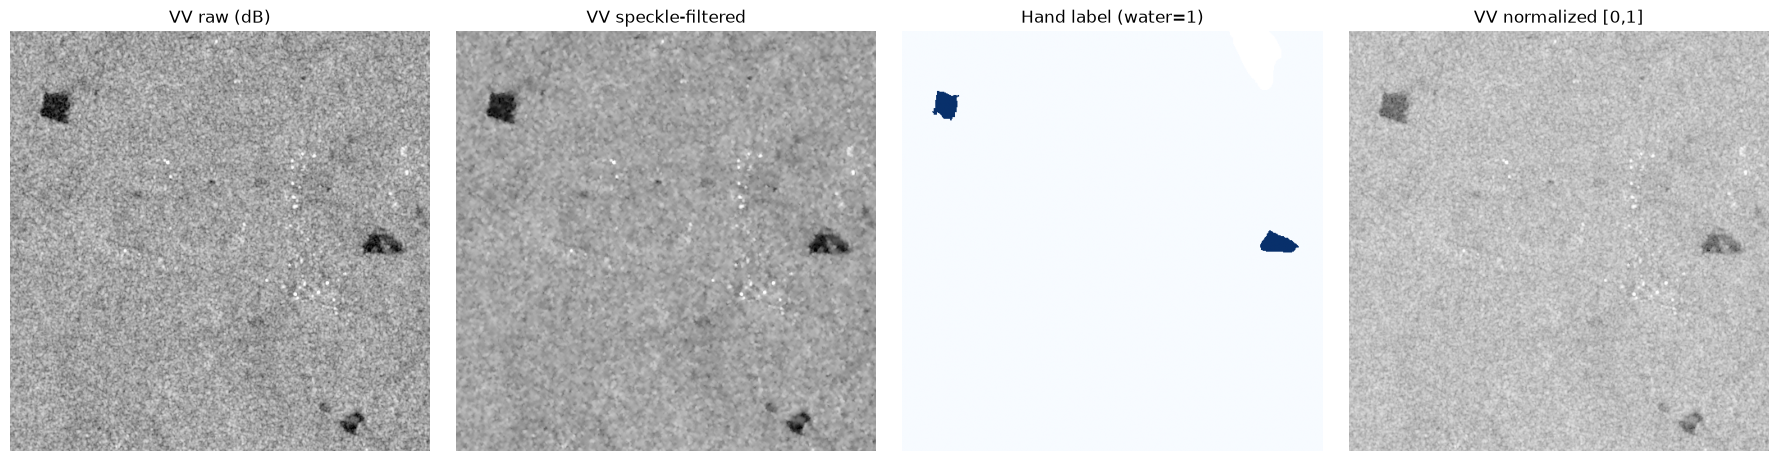

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(s1_raw[0], cmap="gray", vmin=-25, vmax=0); axes[0].set_title("VV raw (dB)")
axes[1].imshow(vv_filtered, cmap="gray", vmin=-25, vmax=0); axes[1].set_title("VV speckle-filtered")
axes[2].imshow(np.where(label == -1, np.nan, label), cmap="Blues"); axes[2].set_title("Hand label (water=1)")
im = axes[3].imshow(normalize_s1(s1_raw)[0], cmap="gray"); axes[3].set_title("VV normalized [0,1]")
for ax in axes: ax.axis("off")
plt.tight_layout()
REPORTS_DIR = os.path.join(_root, "datasets", "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)
plt.savefig(os.path.join(REPORTS_DIR, "02_process_example.png"), dpi=100)
plt.show()

In [8]:
logger.log_metrics({"chips_processed": 1})
logger.finalize()

[02_process] run complete in 1635.638s -> C:\Users\Soumyadip Nayak\Documents\Developer\SphoorthiQ\sphoorthq-geoverse\datasets\reports\runs\b9ee979f-cb80-411c-9722-e0a1cae7506d.json


'C:\\Users\\Soumyadip Nayak\\Documents\\Developer\\SphoorthiQ\\sphoorthq-geoverse\\datasets\\reports\\runs\\b9ee979f-cb80-411c-9722-e0a1cae7506d.json'